<a href="https://colab.research.google.com/github/iljas277/Qlearning_agent_hw/blob/main/transformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Transformers lib from Hugging Face


In [ ]:
import transformers

Pipeline function


In [ ]:
from transformers import pipeline


classifier = pipeline("sentiment-analysis")


classifier("I've been waiting for a Hugging Face for a whole life!")   #detects positive or negative sentence

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

[{'label': 'POSITIVE', 'score': 0.9934513568878174}]

also can use more than 1 sentense in pipeline function

In [ ]:
classifier(["I've been waiting for a Hugging Face for a whole life!",
      "I hate this so much"])

[{'label': 'POSITIVE', 'score': 0.9934513568878174},
 {'label': 'NEGATIVE', 'score': 0.9995144605636597}]

We can use this function in zero-shot-classification. In the example we want to classify the text in 3 categories: 'education', 'buisness', 'politics'.
We get the probabilities of belonging to each class.


In [ ]:
classifier = pipeline("zero-shot-classification")


classifier("This course is about Transformers library", candidate_labels = ['education', 'buisness', 'politics'])

No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

{'sequence': 'This course is about Transformers library',
 'labels': ['buisness', 'education', 'politics'],
 'scores': [0.6077275276184082, 0.3011380136013031, 0.0911344587802887]}

Also we can use this function in text-generation:

In [ ]:
generator = pipeline("text-generation")

generator("We will go")

No model was supplied, defaulted to openai-community/gpt2 and revision 607a30d.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: openai-community/gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': "We will go to the last room and find a group that is all dressed in black. We will talk to them and they will ask about their dreams and they will tell us some things about themselves and their life that is true. We will have them show us all they have. We will have them show how they can do the things that we want them to do and I will show them how to do it. How to make people change.\n\nWhat about your own dreams?\n\nI think of how I wish I could change my life. I wish that I could do something that I feel I can do and that I can make someone better. I wish that I could make a life that I feel I can live in and that I can make someone better. And then I would be able to do so much more. I would be able to do it all. I would be able to do it one way and then the other and I would be able to do it all again. And I can still do it.\n\nYou know what, do you know what the next step would be? I've been thinking about this for years and years but I don't think that I w

We can choose the model  and size of generation if we neeed that:


In [ ]:
generator = pipeline("text-generation", model = 'distilgpt2')
generator("We will go", max_length = 30, num_return_sequences = 2, max_new_tokens = 30)

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'max_length', 'num_return_sequences'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=30) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': 'We will go to the bottom of the list of things I know to be pretty good at, but I have to remember that I am a big fan of the games'},
 {'generated_text': 'We will go back to this weekend to discuss how we will work to make sure this is the best possible experience for our local community, which we will have to play'}]

Fill-mask task is to guess the word in sentence:

In [ ]:
unmasker = pipeline('fill-mask')
unmasker("this course will teach you all about <mask> models.", top_k = 3)

No model was supplied, defaulted to distilbert/distilroberta-base and revision fb53ab8.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

RobertaForMaskedLM LOAD REPORT from: distilbert/distilroberta-base
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

[{'score': 0.16713984310626984,
  'token': 30412,
  'token_str': ' mathematical',
  'sequence': 'this course will teach you all about mathematical models.'},
 {'score': 0.03997702896595001,
  'token': 38163,
  'token_str': ' computational',
  'sequence': 'this course will teach you all about computational models.'},
 {'score': 0.029611892998218536,
  'token': 745,
  'token_str': ' building',
  'sequence': 'this course will teach you all about building models.'}]

Question answering task:

In [ ]:
qa = pipeline("question-answering")
qa(
    question = "Where do I work?",
    context = "My name is Sylvian and I work at HF in Brooklyn."
  )

No model was supplied, defaulted to distilbert/distilbert-base-cased-distilled-squad and revision 564e9b5.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/473 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/261M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

{'score': 0.5068517327308655,
 'start': 33,
 'end': 47,
 'answer': 'HF in Brooklyn'}

and other tasks ...   https://huggingface.co/docs/transformers/main_classes/pipelines

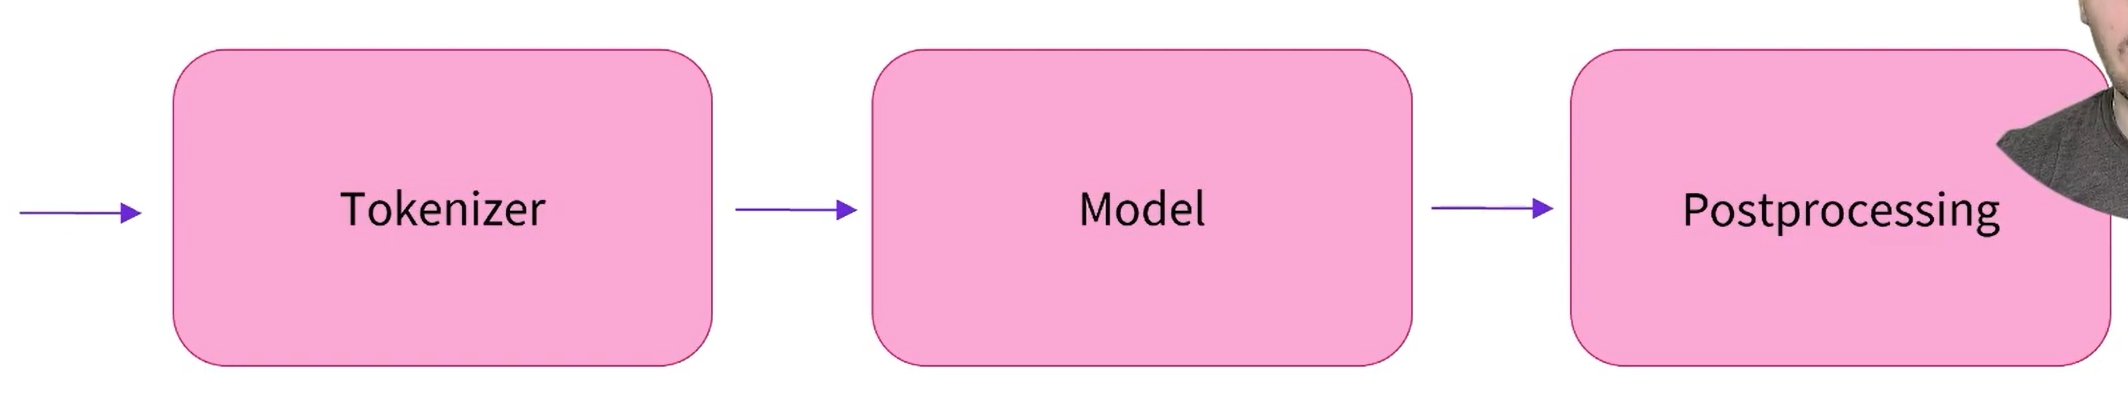

how works pipeline ...

1. Tokenizer   https://huggingface.co/docs/transformers/main_classes/tokenizer
2. Model https://huggingface.co/docs/transformers/main_classes/model
3. Postprocessing (ex. Sofmax func)

**Tokenizers**


They need to "translate the text to numbers". There are 3 types of tokenizers:  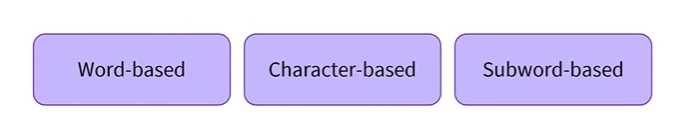


Word-based *tokenization*

The idea is to split text by spaces or other rules like punctuation.
Each word has a specific number or "ID", attributed to it.
There are a lot of words in vocablurary and because of that to contain ids of all words will take up a lot of space. People decided to skip some inimportant word and mark them as unknown, also dont give another id to each form of word, because they have similar meaning.



Character-based *tokenization*


 idea to split the text by the characters. every character has unique id. this way we can embede all words using few ids than in word-based tokenization!  But this type also have disadvabtages. we dont hold an information about whole word.  Also texts tokenized by character tokenization take out a lot of space.


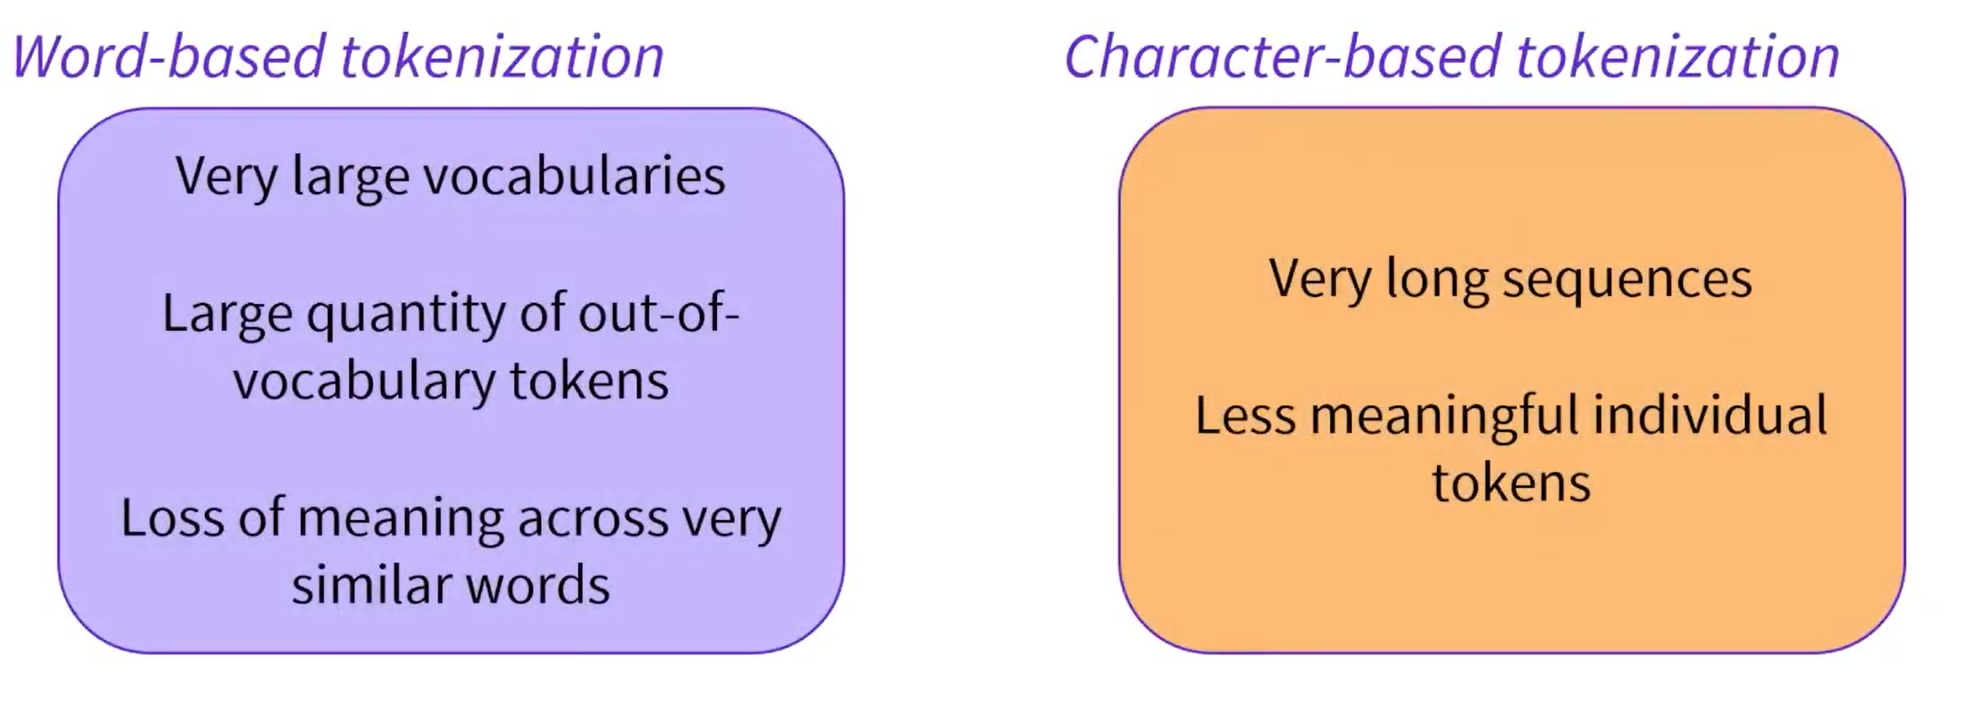

Subword-based *tokenization*

the idea to find a middle ground between large vocabluraries, large sequences, large number of out-of-vocablurary tokenss, loss of similar words.


the way: frequently used words shouldn't be split into smaller subwords, but rare words should be decomposed into meaningful subwords.

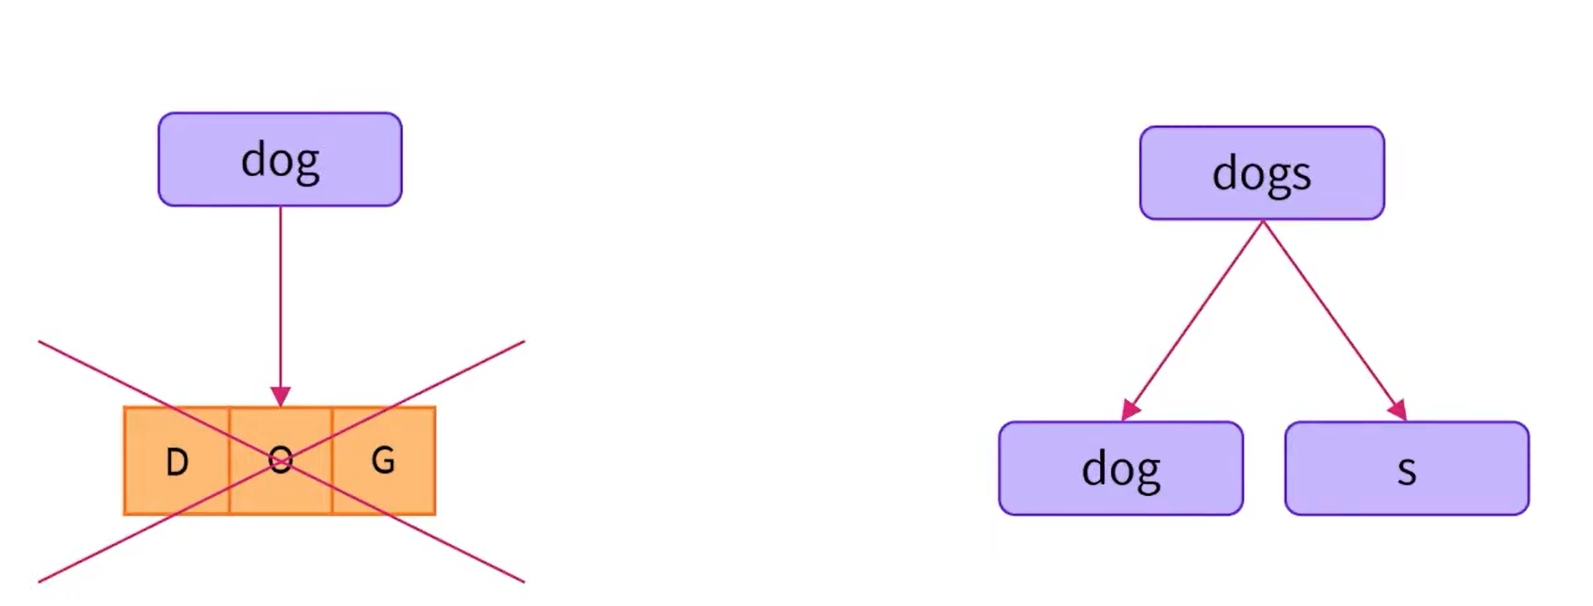

In [4]:
from transformers import AutoTokenizer


tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

inputs = tokenizer("Let's try to tokenize!")

print(inputs["input_ids"])

[101, 2292, 1005, 1055, 3046, 2000, 19204, 4697, 999, 102]


In [8]:
token = tokenizer.tokenize("Let's try to tokenize!")
tokens = tokenizer.convert_tokens_to_ids(token) #without special tokens
tokens

[2292, 1005, 1055, 3046, 2000, 19204, 4697, 999]